If we have a centered data matrix $X$ (where the mean of each column has already been subtracted to be zero), the sample covariance matrix $\Sigma$ is calculated using matrix multiplication:$$\Sigma = \frac{1}{n - 1} X^T X$$where $n$ is the number of data points (rows).

**The Challenge**

Imagine you have a tiny dataset of $n = 3$ observations (rows) and $2$ variables/features (columns), which is already centered:$$X = \begin{bmatrix} 1 & 2 \\ -1 & -1 \\ 0 & -1 \end{bmatrix}$$



1.   Compute the transpose matrix, $X^T$.
2.   Perform the matrix multiplication $X^T X$.
3. Divide by $n - 1$ (where $n = 3$) to find the final $2 \times 2$ covariance matrix $\Sigma$.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
x = np.array([[1, 2], [-1, -1], [0, -1]])

x_transpose = np.matrix_transpose(x)

x_transpose

array([[ 1, -1,  0],
       [ 2, -1, -1]])

In [10]:
multiplied = np.matmul(x_transpose, x)
multiplied

array([[2, 3],
       [3, 6]])

In [11]:
result = multiplied / 2
result

array([[1. , 1.5],
       [1.5, 3. ]])

In [13]:
mean = [0,0]

cov = result.copy()

In [14]:
data = np.random.multivariate_normal(mean, cov, size=500)

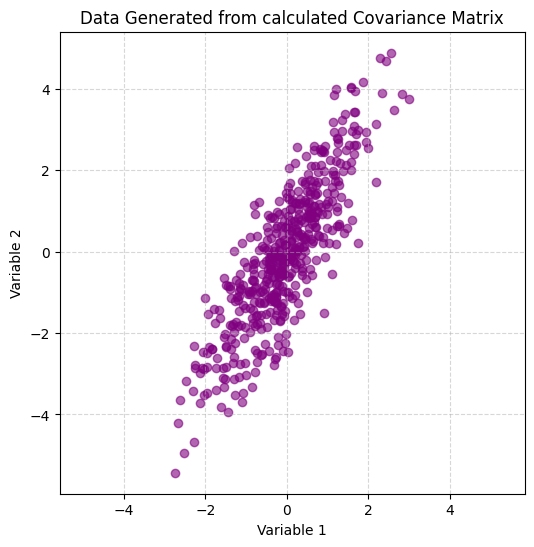

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(data[:,0], data[:,1], alpha=0.6, color="purple")

plt.title("Data Generated from calculated Covariance Matrix")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.axis("equal")
plt.show()

# Reading the Covariance Matrix

**The Off-Diagonal Covariance**

Slanted Up / Positive Slope (/): If the oval tilts upward to the right, your covariance is positive. This means when Variable X goes up, Variable Y tends to go up too (e.g., height and weight).

Slanted Down / Negative Slope (\): If the oval tilts downward, your covariance is negative. When X goes up, Y goes down (e.g., hours spent playing video games vs. test scores).

Sitting Straight (| or -): If the oval has no tilt and sits perfectly straight up-and-down or flat, your covariance is zero. X and Y don't care about each other.



---

**The Diagonal Variances**

Fat and Round (Circle-ish): If the width and height are about equal, the variances are similar. The variables have similar amounts of spread.

Skinny and Long (A Long Cigars/Ellipse): One variance is much larger than the other. This tells you the data stretches out heavily in one main direction.


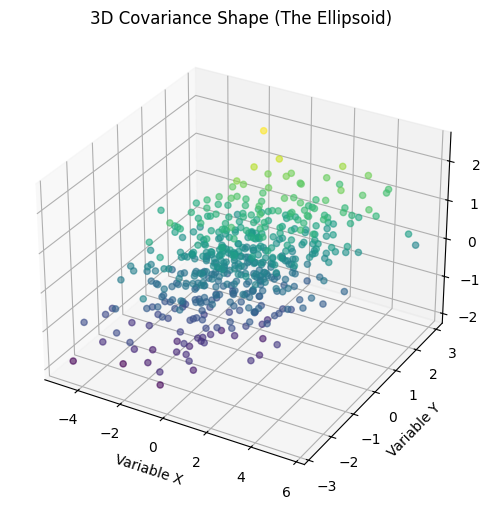

In [17]:
# Define the center (mean) in 3D space
mean_3d = [0, 0, 0]

# Define a 3D covariance matrix
# Notice how the diagonal has different sizes, and off-diagonals introduce tilts
cov_3d = [[3.0, 1.0, 0.2], [1.0, 1.0, 0.5], [0.2, 0.5, 0.5]]

# Generate 500 data points using 3D blueprint
data_3d = np.random.multivariate_normal(mean_3d, cov_3d, 500)

# Plot the 3D ellipsoid cloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    data_3d[:, 0],
    data_3d[:, 1],
    data_3d[:, 2],
    c=data_3d[:, 2],
    cmap="viridis",
    alpha=0.6,
)

ax.set_title("3D Covariance Shape (The Ellipsoid)")
ax.set_xlabel("Variable X")
ax.set_ylabel("Variable Y")
ax.set_zlabel("Variable Z")
plt.show()

# Eigendecomposition

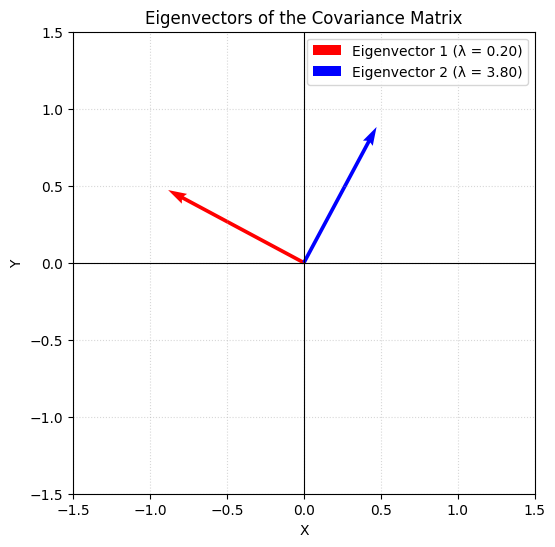

In [26]:
# Covariance matrix
cov = np.array([
    [1.0, 1.5],
    [1.5, 3.0]
])

# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov)

fig, ax = plt.subplots(figsize=(6, 6))

# Colors
colors = ["red", "blue"]

# Plot eigenvectors
for i in range(len(eigenvalues)):
    vec = eigenvectors[:, i]

    ax.quiver(
        0, 0,                 # Start at the origin
        vec[0], vec[1],       # Eigenvector direction
        angles="xy",
        scale_units="xy",
        scale=1,
        color=colors[i],
        width=0.008,
        label=f"Eigenvector {i+1} (λ = {eigenvalues[i]:.2f})"
    )

# the origin at the center
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# Equal x and y scaling
ax.set_aspect("equal", adjustable="box")

# Centered axes
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(True, linestyle=":", alpha=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Eigenvectors of the Covariance Matrix")

ax.legend()

plt.show()

Eigenvector ($v$): That special arrow that refuses to change its direction. ("eigen" means "own" or "characteristic" in German—it's the vector's own special direction).  

Eigenvalue ($\lambda$): The scaling factor. It is simply the multiplier that tells how much that special arrow got stretched or shrunk.

Eigenvalues (The Strengths):
 [0.19722436 3.80277564]

Eigenvectors (The Directions):
 [[-0.8816746  -0.47185793]
 [ 0.47185793 -0.8816746 ]]


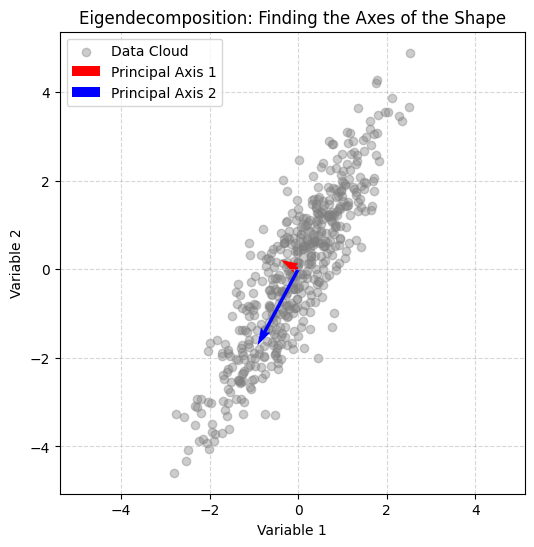

In [20]:
cov = np.array([[1.0, 1.5], [1.5, 3.0]])

eigenvalues, eigenvectors = np.linalg.eig(cov)

print("Eigenvalues (The Strengths):\n", eigenvalues)
print("\nEigenvectors (The Directions):\n", eigenvectors)

# plot the data and draw the eigenvectors as arrows (quiver)
mean = [0, 0]
data = np.random.multivariate_normal(mean, cov, 500)

plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.4, color="gray", label="Data Cloud")

# Draw the eigenvectors originating from the mean [0, 0]
# We scale the eigenvectors by the square root of eigenvalues to match the spread
for i in range(len(eigenvalues)):
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i])
    plt.quiver(
        mean[0],
        mean[1],
        vec[0],
        vec[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=["red", "blue"][i],
        label=f"Principal Axis {i+1}",
    )

plt.title("Eigendecomposition: Finding the Axes of the Shape")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.axis("equal")
plt.show()

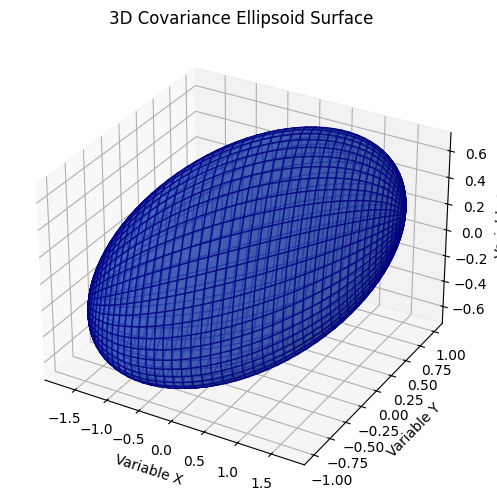

In [18]:
mean = np.array([0, 0, 0])
cov = np.array([[3.0, 1.0, 0.2], [1.0, 1.0, 0.5], [0.2, 0.5, 0.5]])

# Generate a standard unit sphere mesh
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
xx = np.outer(np.cos(u), np.sin(v))
yy = np.outer(np.sin(u), np.sin(v))
zz = np.outer(np.ones_like(u), np.cos(v))
sphere_pts = np.array([xx.flatten(), yy.flatten(), zz.flatten()])

# Use Eigen-decomposition to stretch and tilt the sphere to match the covariance shape
eigenvals, eigenvecs = np.linalg.eigh(cov)
# Scale the sphere by the square root of the eigenvalues (standard deviations)
# and rotate it using the eigenvectors
scaling = np.diag(np.sqrt(eigenvals))
transform_matrix = eigenvecs @ scaling
transformed_pts = transform_matrix @ sphere_pts

# Reshape back to grid format for surface plotting
x_surf = transformed_pts[0, :].reshape(xx.shape) + mean[0]
y_surf = transformed_pts[1, :].reshape(yy.shape) + mean[1]
z_surf = transformed_pts[2, :].reshape(zz.shape) + mean[2]

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.plot_surface(
    x_surf, y_surf, z_surf, color="royalblue", alpha=0.7, edgecolor="navy"
)

ax.set_title("3D Covariance Ellipsoid Surface")
ax.set_xlabel("Variable X")
ax.set_ylabel("Variable Y")
ax.set_zlabel("Variable Z")
plt.show()